In [ ]:
from google.colab import drive
drive.mount('/content/drive')

embedding_dir = "/content/drive/MyDrive/embeddings"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load Embeddings
- dataset:
    - positive training data
    - negative training data
    - positive test data
    - negative test data

In [ ]:
import numpy as np
import os

pos_train = np.load(os.path.join(embedding_dir, "positive_train.npy"))
neg_train = np.load(os.path.join(embedding_dir, "negative_train.npy"))
pos_test = np.load(os.path.join(embedding_dir, "positive_test.npy"))
neg_test = np.load(os.path.join(embedding_dir, "negative_test.npy"))

y_pos_train = np.ones(len(pos_train), dtype=int)
y_neg_train = np.zeros(len(neg_train), dtype=int)

y_pos_test = np.ones(len(pos_test), dtype=int)
y_neg_test = np.zeros(len(neg_test), dtype=int)

X_train_all = np.concatenate([pos_train, neg_train], axis=0)
y_train_all = np.concatenate([y_pos_train, y_neg_train], axis=0)

X_test = np.concatenate([pos_test, neg_test], axis=0)
y_test = np.concatenate([y_pos_test, y_neg_test], axis=0)

print(pos_train.shape)
print(neg_train.shape)
print(pos_test.shape)
print(neg_test.shape)

(3338, 185, 320)
(3338, 185, 320)
(835, 185, 320)
(835, 185, 320)


## Split validation dataset form training dataset

The original dataset had already been divided into training and test sets.  
In this step, we further split the original training set into a final training set and a validation set.

- Original split:
  - Training set: 80%
  - Test set: 20%

- Additional split from the original training set:
  - Final training set: 80% of the original training set
  - Validation set: 20% of the original training set

Therefore, the final dataset ratio is approximately:

- Training set: 64%
- Validation set: 16%
- Test set: 20%

The validation set is used for model comparison and parameter selection, while the test set is reserved for final evaluation.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_all,
    y_train_all,
    test_size=0.2,
    random_state=42,
    stratify=y_train_all
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (5340, 185, 320)
X_val: (1336, 185, 320)
X_test: (1670, 185, 320)


## Sequence-level Embedding Extraction

Because this task focuses on AMP classification, the prediction target is the entire peptide sequence rather than a specific residue position. Therefore, instead of extracting the embedding from the center residue, we aggregate the residue-level embeddings across the whole sequence.

In this project, ESM-2 first generates contextual embeddings for all amino acid residues in each peptide sequence. Then, mean pooling is applied over all residue embeddings to obtain one fixed-size 320-dimensional sequence-level feature vector, which is used as the input to downstream classifiers.

In [ ]:
X_train = X_train.mean(axis=1)
X_val   = X_val.mean(axis=1)
X_test  = X_test.mean(axis=1)

print("X_train sequence-level:", X_train.shape)
print("X_val sequence-level:", X_val.shape)
print("X_test sequence-level:", X_test.shape)

X_train sequence-level: (5340, 320)
X_val sequence-level: (1336, 320)
X_test sequence-level: (1670, 320)


# Training Model & Evaluation

After extracting the center K embeddings, each sample is represented as a 320-dimensional feature vector.  
We trained three downstream classifiers to compare their performance:

- Logistic Regression: used as a simple baseline linear classifier.
- Random Forest: an ensemble model that can capture nonlinear feature relationships.
- SVM with RBF kernel: a nonlinear classifier that can learn more flexible decision boundaries.

For all models, `class_weight="balanced"` was used to reduce the influence of class imbalance.  
The models were trained only on the training set. The validation set was used for model comparison, and the test set was reserved for final evaluation.

## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

## SVM

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    probability=True,
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train, y_train)

SVC(class_weight='balanced', probability=True, random_state=42)

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

def evaluate_model(model, X, y):
    y_pred = model.predict(X)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X)[:, 1]
    else:
        y_prob = model.decision_function(X)

    results = {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall": recall_score(y, y_pred, zero_division=0),
        "F1-score": f1_score(y, y_pred, zero_division=0),
        "AUROC": roc_auc_score(y, y_prob),
        "AUPRC": average_precision_score(y, y_prob),
        "Confusion Matrix": confusion_matrix(y, y_pred)
    }

    return results

## Validation evaluation

In [ ]:
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "SVM": svm_model
}

for name, model in models.items():
    result = evaluate_model(model, X_val, y_val)
    print("=====", name, "Validation Results =====")
    for k, v in result.items():
        print(k, ":", v)
    print()

===== Logistic Regression Validation Results =====
Accuracy : 0.8637724550898204
Precision : 0.8869426751592356
Recall : 0.8338323353293413
F1-score : 0.8595679012345679
AUROC : 0.9431204955358744
AUPRC : 0.9502539123842794
Confusion Matrix : [[597  71]
 [111 557]]

===== Random Forest Validation Results =====
Accuracy : 0.8832335329341318
Precision : 0.919672131147541
Recall : 0.8398203592814372
F1-score : 0.8779342723004695
AUROC : 0.9546460970275019
AUPRC : 0.959509822811778
Confusion Matrix : [[619  49]
 [107 561]]

===== SVM Validation Results =====
Accuracy : 0.8532934131736527
Precision : 0.9027303754266212
Recall : 0.7919161676646707
F1-score : 0.8437001594896332
AUROC : 0.9300822008677256
AUPRC : 0.9382477963713644
Confusion Matrix : [[611  57]
 [139 529]]



## Test evaluation

In [ ]:
import pandas as pd

test_results = []

metrics_df = pd.DataFrame(test_results)
metrics_df

for name, model in models.items():
    result = evaluate_model(model, X_test, y_test)

    test_results.append({
        "Model": name,
        "Accuracy": result["Accuracy"],
        "Precision": result["Precision"],
        "Recall": result["Recall"],
        "F1-score": result["F1-score"],
        "AUROC": result["AUROC"],
        "AUPRC": result["AUPRC"]
    })

metrics_df = pd.DataFrame(test_results)
metrics_df

,Model,Accuracy,Precision,Recall,F1-score,AUROC,AUPRC
0,Logistic Regression,0.869461,0.892994,0.839521,0.865432,0.944150,0.950808
1,Random Forest,0.886228,0.917206,0.849102,0.881841,0.964815,0.966685
2,SVM,0.844311,0.898752,0.776048,0.832905,0.927768,0.936702


In [ ]:
import os

os.makedirs("content/results", exist_ok=True)

metrics_df.to_csv("/content/drive/MyDrive/results/metrics.csv", index=False)

In [ ]:
best_model_name = metrics_df.sort_values("F1-score", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

print("Best model:", best_model_name)

Best model: Random Forest


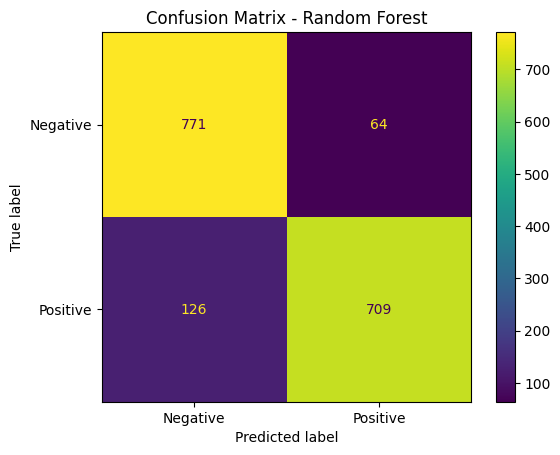

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

y_test_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.savefig("/content/drive/MyDrive/results/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()